In [ ]:
# Load libraries
import pandas as pd
import time
import random
import os
import pickle
import matplotlib.pyplot as plt

In [ ]:
# mount my google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Folder to save the results
DATAFOLDER = "drive/MyDrive/SynBio/20251104"

In [ ]:
# Load all pickled data files from PART1 to PART7
all_pubs = []
for i in range(1, 8):
    filename = DATAFOLDER + f'/raw_dataset_pickled_PART{i}'
    try:
        with open(filename, 'rb') as f:
            data = pickle.load(f)
            all_pubs.append(data)
    except FileNotFoundError:
        print(f"File not found: {filename}")

# Concatenate all DataFrames
pubs = pd.concat(all_pubs, ignore_index=True)

# Retain only unique rows based on the 'id' column
pubs.drop_duplicates(subset='id', inplace=True)

# Display the first few rows and the shape of the combined DataFrame
display(pubs.head())
print(f"Shape of the combined DataFrame: {pubs.shape}")

,id,doi,type,title,year,times_cited,abstract,concepts,journal.title,researchers,research_org_names,research_org_country_names,reference_ids,is_oa,is_retracted
0,https://openalex.org/W4247420482,https://doi.org/10.1038/nbt1296-1675,article,Expression monitoring by hybridization to high...,1996,2855,,"[Oligonucleotide, Sequence (biology), Computat...","{'id': 'https://openalex.org/S106963461', 'tit...","[{'last_name': 'David J. Lockhart'}, {'last_na...",[None],[],"[https://openalex.org/W2159511216, https://ope...","{'is_oa': False, 'oa_pdf': None}",False
1,https://openalex.org/W1567090568,https://doi.org/10.1038/28998,article,Design and self-assembly of two-dimensional DN...,1998,2826,,"[Intermolecular force, Nanometre, DNA, Nanotec...","{'id': 'https://openalex.org/S137773608', 'tit...","[{'last_name': 'Erik Winfree'}, {'last_name': ...","[California Institute of Technology, New York ...",[USA],"[https://openalex.org/W2038125628, https://ope...","{'is_oa': False, 'oa_pdf': None}",False
2,https://openalex.org/W2091309425,https://doi.org/10.1093/nar/17.19.7843,article,Isolation and direct complete nucleotide deter...,1989,2674,Using a set of synthetic oligonucleotides homo...,"[Biology, Nucleic acid sequence, Subcloning, G...","{'id': 'https://openalex.org/S134668137', 'tit...","[{'last_name': 'Ulrike Edwards'}, {'last_name'...","[Medizinische Hochschule Hannover, None]",[Germany],"[https://openalex.org/W2410376331, https://ope...","{'is_oa': False, 'oa_pdf': None}",False
3,https://openalex.org/W2092784580,https://doi.org/10.1016/0022-2836(75)90213-2,article,A rapid method for determining sequences in DN...,1975,2656,,"[DNA polymerase, DNA polymerase I, DNA clamp, ...","{'id': 'https://openalex.org/S46058472', 'titl...","[{'last_name': 'Frederick Sanger'}, {'last_nam...","[MRC Laboratory of Molecular Biology, Medical ...",[United Kingdom],"[https://openalex.org/W1567976916, https://ope...","{'is_oa': False, 'oa_pdf': None}",False
4,https://openalex.org/W2037457710,https://doi.org/10.1093/nar/9.2.309,article,A system for shotgun DNA sequencing,1981,2648,A multipurpose cloning site has been introduce...,"[Biology, Restriction enzyme, Shotgun sequenci...","{'id': 'https://openalex.org/S134668137', 'tit...","[{'last_name': 'Joachim Messing'}, {'last_name...","[University of California, Davis, Genentech, M...","[Germany, USA]","[https://openalex.org/W2066739041, https://ope...","{'is_oa': False, 'oa_pdf': None}",False


Shape of the combined DataFrame: (29924, 15)


In [ ]:
# Save serialized version of data from Dimensions
file = open(DATAFOLDER + '/raw_dataset_pickled_COMPLETED', 'wb')
pickle.dump(pubs, file)
file.close()

In [ ]:
pubs.columns

Index(['id', 'doi', 'type', 'title', 'year', 'times_cited', 'abstract',
       'concepts', 'journal.title', 'researchers', 'research_org_names',
       'research_org_country_names', 'reference_ids', 'is_oa', 'is_retracted'],
      dtype='object')

# To Web of Science format

In [ ]:
column_rename_map = {
    'id': 'UT',
    'title': 'TI',
    'year': 'PY',
    'times_cited': 'Z9',
    'abstract': 'AB',
    'concepts': 'DE',
    'journal.title': 'SO',
    'researchers': 'AU',
    'research_org_names': 'Institutions',
    'research_org_country_names': 'Countries',
    'reference_ids': 'CR',
    'doi': 'DI',
    #'is_oa': 'OA',
    #'is_retracted': 'is_retracted',
    'type': 'PT'
}

pubs.rename(columns=column_rename_map, inplace=True)

print("New column names:")
print(pubs.columns)

New column names:
Index(['UT', 'DI', 'PT', 'TI', 'PY', 'Z9', 'AB', 'DE', 'SO', 'AU',
       'Institutions', 'Countries', 'CR', 'is_oa', 'is_retracted'],
      dtype='object')


In [ ]:
pubs['DI'] = pubs['DI'].astype(str).str.replace('https://doi.org/', '', regex=False)
print("First 5 entries of the updated 'DI' column:")
print(pubs['DI'].head())

# In Wos we match by DOI, but here the matching happens with UT. So we will store the actaul DOI as 'DI_DOI' and copy UT as 'DI'
pubs['DI_DOI'] = pubs['DI']
pubs['DI'] = pubs['UT']

First 5 entries of the updated 'DI' column:
0            10.1038/nbt1296-1675
1                   10.1038/28998
2          10.1093/nar/17.19.7843
3    10.1016/0022-2836(75)90213-2
4             10.1093/nar/9.2.309
Name: DI, dtype: object


In [ ]:
import numpy as np

def format_list_column(data):
    if isinstance(data, list):
        # Filter out any non-string elements if present and join
        return "; ".join(str(item) for item in data if item is not None)
    elif pd.isna(data):
        return "" # Handle NaN values as empty strings
    else:
        return str(data) # Convert other non-list types to string

columns_to_reformat = ['DE', 'Institutions', 'Countries', 'CR']

for col in columns_to_reformat:
    pubs[col] = pubs[col].apply(format_list_column)

print("First 5 entries of reformatted columns:")
for col in columns_to_reformat:
    print(f"\n--- {col} ---")
    display(pubs[col].head())

First 5 entries of reformatted columns:

--- DE ---


,DE
0,Oligonucleotide; Sequence (biology); Computati...
1,Intermolecular force; Nanometre; DNA; Nanotech...
2,Biology; Nucleic acid sequence; Subcloning; Ge...
3,DNA polymerase; DNA polymerase I; DNA clamp; D...
4,Biology; Restriction enzyme; Shotgun sequencin...



--- Institutions ---


,Institutions
0,
1,California Institute of Technology; New York U...
2,Medizinische Hochschule Hannover
3,MRC Laboratory of Molecular Biology; Medical R...
4,"University of California, Davis; Genentech; Ma..."



--- Countries ---


,Countries
0,
1,USA
2,Germany
3,United Kingdom
4,Germany; USA



--- CR ---


,CR
0,https://openalex.org/W2159511216; https://open...
1,https://openalex.org/W2038125628; https://open...
2,https://openalex.org/W2410376331; https://open...
3,https://openalex.org/W1567976916; https://open...
4,https://openalex.org/W2066739041; https://open...


In [ ]:
def extract_journal_title(journal_entry):
    if isinstance(journal_entry, dict) and 'title' in journal_entry:
        return journal_entry['title']
    return None  # Return None or an empty string for entries that are not dictionaries or lack a title

pubs['SO'] = pubs['SO'].apply(extract_journal_title)

print("First 5 entries of the updated 'SO' column:")
display(pubs['SO'].head())

First 5 entries of the updated 'SO' column:


,SO
0,Nature Biotechnology
1,Nature
2,Nucleic Acids Research
3,Journal of Molecular Biology
4,Nucleic Acids Research


In [ ]:
def extract_oa_bool(journal_entry):
    if isinstance(journal_entry, dict) and 'is_oa' in journal_entry:
        return journal_entry['is_oa']
    return None  # Return None or an empty string for entries that are not dictionaries or lack a title

pubs['is_oa'] = pubs['is_oa'].apply(extract_oa_bool)

print("First 5 entries of the updated 'is_oa' column:")
display(pubs['is_oa'].head())

First 5 entries of the updated 'is_oa' column:


,is_oa
0,False
1,False
2,False
3,False
4,False


In [ ]:
def format_researchers_au(researchers_list):
    if isinstance(researchers_list, list) and researchers_list:
        last_names = []
        for researcher in researchers_list:
            if isinstance(researcher, dict) and 'last_name' in researcher:
                last_names.append(researcher['last_name'])
        return "; ".join(last_names)
    return ""

pubs['AU'] = pubs['AU'].apply(format_researchers_au)

print("First 5 entries of the updated 'AU' column:")
display(pubs['AU'].head())

First 5 entries of the updated 'AU' column:


,AU
0,David J. Lockhart; Helin Dong; Michael C. Byrn...
1,Erik Winfree; Furong Liu; Lisa A. Wenzler; Nad...
2,Ulrike Edwards; T. Rogall; Helmut Blöcker; Mon...
3,Frederick Sanger; Alan Coulson
4,Joachim Messing; Roberto Crea; Peter H. Seeburg


In [ ]:
output_filename = DATAFOLDER + '/igem_dataset_openalex.txt'
pubs.to_csv(output_filename, sep='\t', index=False)
print(f"DataFrame successfully saved to {output_filename}")

DataFrame successfully saved to drive/MyDrive/SynBio/20251104/igem_dataset_openalex.txt




---
# Overall dataset statistics


In [ ]:
# Check how many rows have a list with length > 0 in the 'reference_ids' column
count_with_references = pubs['reference_ids'].apply(lambda x: len(x) > 0).sum()

print(f"Number of rows with a list length > 0 in 'reference_ids': {count_with_references} ; {count_with_references / len(pubs)}")

Number of rows with a list length > 0 in 'reference_ids': 22313 ; 0.7456556610078866


In [ ]:
# Check how many rows contain an abstract
count_with_abstract = pubs['abstract'].apply(lambda x: len(str(x).strip()) > 0).sum()

print(f"Number of rows with an abstract: {count_with_abstract}; {count_with_abstract / len(pubs)}")

Number of rows with an abstract: 20972; 0.7008421334046251


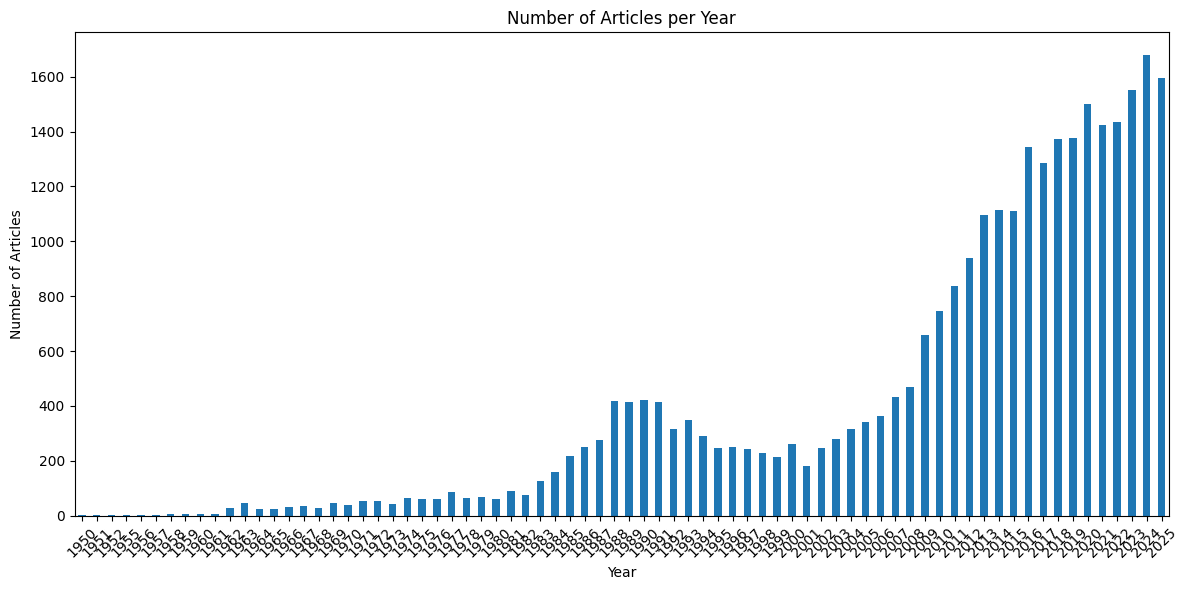

In [ ]:
# Group by year and count the number of articles
articles_per_year = pubs['year'].value_counts().sort_index()

# Plot the results
plt.figure(figsize=(12, 6))
articles_per_year.plot(kind='bar')
plt.title('Number of Articles per Year')
plt.xlabel('Year')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

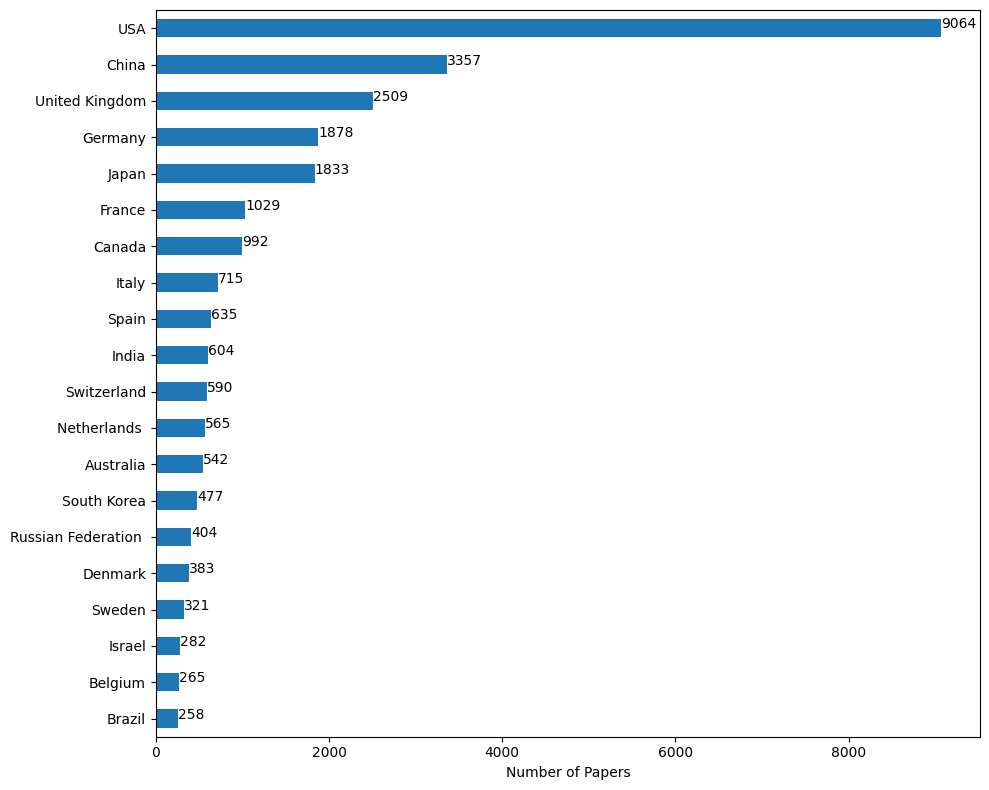

In [ ]:
country_counts = {}
for index, row in pubs.iterrows():
    countries = row['research_org_country_names']
    #countries = row['research_org_names']
    #countries = row['concepts']
    if isinstance(countries, list) and countries:
        for country in countries:
            if country in country_counts:
                country_counts[country] += 1
            else:
                country_counts[country] = 1

# Summary
country_counts_series = pd.Series(country_counts)
top_countries = country_counts_series.sort_values(ascending=False).head(20)

# Plot
plt.figure(figsize=(10, 8))
top_countries.plot(kind='barh')
#plt.title('Top 20 Countries by Number of Papers')
plt.xlabel('Number of Papers')
#plt.ylabel('Country')
plt.gca().invert_yaxis() # Invert y-axis to have the largest bar at the top

# Add the actual values to the bars
for index, value in enumerate(top_countries):
    plt.text(value, index, str(value))

plt.tight_layout()
plt.show()

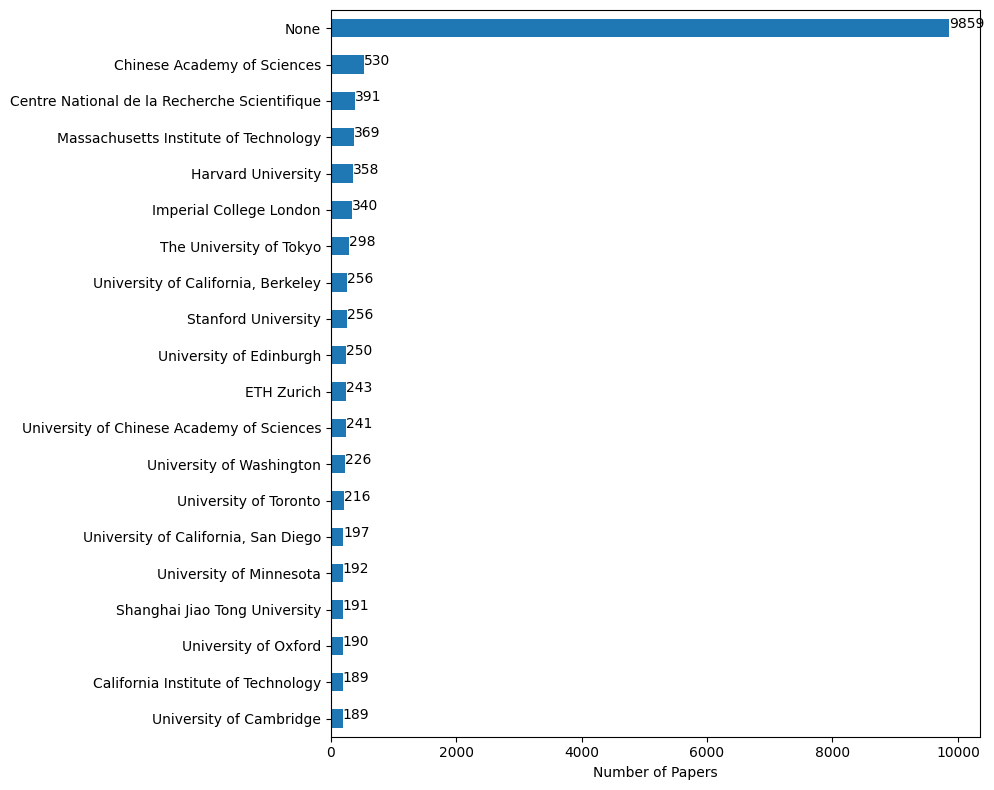

In [ ]:
country_counts = {}
for index, row in pubs.iterrows():
    #countries = row['research_org_country_names']
    countries = row['research_org_names']
    #countries = row['concepts']
    if isinstance(countries, list) and countries:
        for country in countries:
            if country in country_counts:
                country_counts[country] += 1
            else:
                country_counts[country] = 1

# Summary
country_counts_series = pd.Series(country_counts)
top_countries = country_counts_series.sort_values(ascending=False).head(20)

# Plot
plt.figure(figsize=(10, 8))
top_countries.plot(kind='barh')
#plt.title('Top 20 Countries by Number of Papers')
plt.xlabel('Number of Papers')
#plt.ylabel('Country')
plt.gca().invert_yaxis() # Invert y-axis to have the largest bar at the top

# Add the actual values to the bars
for index, value in enumerate(top_countries):
    plt.text(value, index, str(value))

plt.tight_layout()
plt.show()

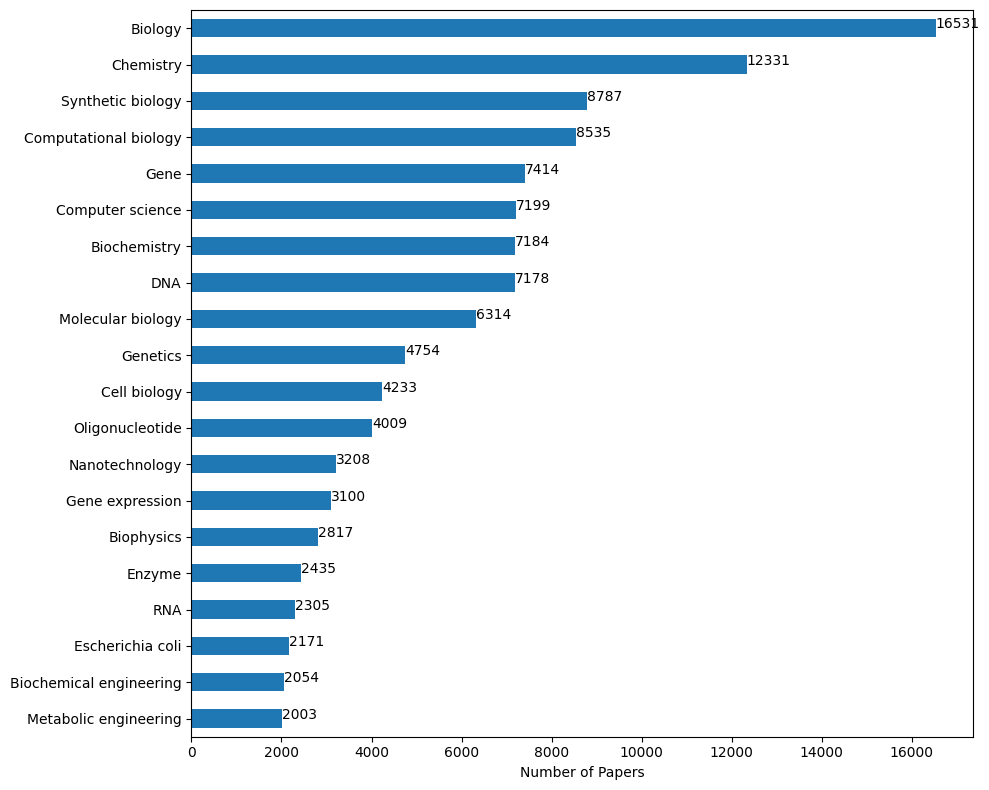

In [ ]:
country_counts = {}
for index, row in pubs.iterrows():
    #countries = row['research_org_country_names']
    #countries = row['research_org_names']
    countries = row['concepts']
    if isinstance(countries, list) and countries:
        for country in countries:
            if country in country_counts:
                country_counts[country] += 1
            else:
                country_counts[country] = 1

# Summary
country_counts_series = pd.Series(country_counts)
top_countries = country_counts_series.sort_values(ascending=False).head(20)

# Plot
plt.figure(figsize=(10, 8))
top_countries.plot(kind='barh')
#plt.title('Top 20 Countries by Number of Papers')
plt.xlabel('Number of Papers')
#plt.ylabel('Country')
plt.gca().invert_yaxis() # Invert y-axis to have the largest bar at the top

# Add the actual values to the bars
for index, value in enumerate(top_countries):
    plt.text(value, index, str(value))

plt.tight_layout()
plt.show()

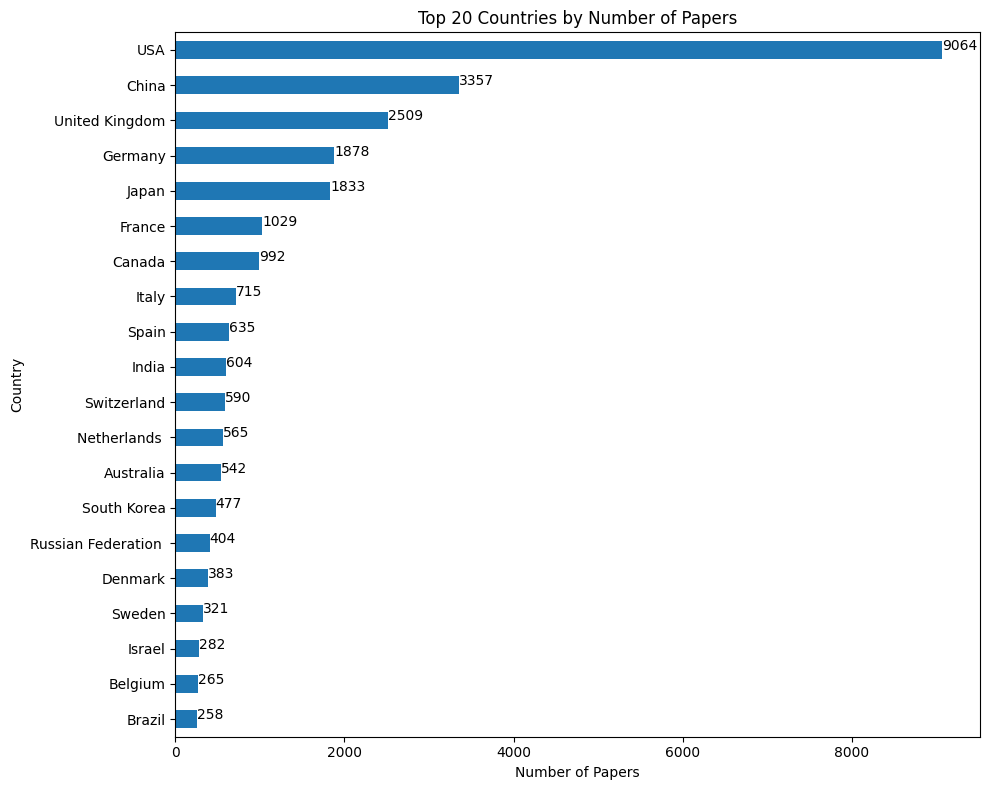